# Exploratory Data Analysis
## Blast-Induced Deformation of RC Columns
### Research-Grade EDA Notebook

---

> **Purpose:** This notebook performs a thorough exploratory data analysis (EDA) of the experimental
> dataset used to model peak deformation of reinforced concrete (RC) columns under blast loading.
> The analysis covers data profiling, feature engineering, distributional characterisation,
> correlation structure, and training-set diagnostics — all formatted to publication standards.

---


## 1. Library Imports

All required libraries are imported once at the top of the notebook following PEP 8 conventions.


In [1]:
# ==========================================
# 1. LIBRARY IMPORTS
# ==========================================

# --- Standard library ---
import warnings

# --- Numerical & data ---
import numpy as np
import pandas as pd

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

# --- Statistics ---
from scipy import stats
from scipy.stats import pearsonr, spearmanr, shapiro, kstest

# --- Machine learning (train/test split) ---
from sklearn.model_selection import train_test_split

# --- Display helpers ---
from IPython.display import display

warnings.filterwarnings("ignore")

# ── Global plot aesthetics ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":          150,
    "savefig.dpi":         300,
    "font.family":         "serif",
    "font.size":           11,
    "axes.labelsize":      12,
    "axes.titlesize":      13,
    "axes.titleweight":    "bold",
    "axes.labelweight":    "bold",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "xtick.labelsize":     10,
    "ytick.labelsize":     10,
    "legend.fontsize":     10,
    "legend.framealpha":   0.7,
    "figure.facecolor":    "white",
    "axes.facecolor":      "#FAFAFA",
    "grid.color":          "#E0E0E0",
    "grid.linestyle":      "--",
    "grid.linewidth":      0.6,
    "axes.grid":           True,
})

PALETTE   = "muted"
SEED      = 42
print("✓ Imports loaded successfully.")


✓ Imports loaded successfully.


---
## 2. Data Loading & Initial Inspection

The raw dataset is loaded from the Excel file and subjected to an initial sanity check.


In [2]:
# ==========================================
# 2. DATA LOADING
# ==========================================

DATA_PATH = "data-p.xlsx"

df_raw = pd.read_excel(DATA_PATH)

print(f"Dataset loaded  →  {df_raw.shape[0]} rows  ×  {df_raw.shape[1]} columns")
print("\nColumn names:")
for c in df_raw.columns:
    print(f"  • {c}")


Dataset loaded  →  147 rows  ×  10 columns

Column names:
  • shape of the cross section
  • dimensions 
  • span length of specimen
  • grade of concrete(Mpa)
  • yield strength of the steel (Mpa)
  • Rx2
  • scaled stand off distance
  • axial load ratio
  • confinement
  • peak deformation (mm)


In [3]:
# ── Preview ────────────────────────────────────────────────────────────────
display(df_raw.head(10).style.set_caption("Table 1 — First 10 rows of the raw dataset")
        .set_table_styles([{"selector": "caption",
                            "props": [("font-size", "13px"),
                                      ("font-weight", "bold"),
                                      ("text-align", "left")]}]))


,shape of the cross section,dimensions,span length of specimen,grade of concrete(Mpa),yield strength of the steel (Mpa),Rx2,scaled stand off distance,axial load ratio,confinement,peak deformation (mm)
0,square,200,2500,47.460000,484.740000,1,0.458566,0.000000,0.820000,41.800000
1,square,200,2500,47.460000,484.740000,1,0.458566,0.050000,0.820000,41.600000
2,square,200,2500,47.460000,484.740000,1,0.458566,0.100000,0.820000,41.500000
3,square,200,2500,47.460000,484.740000,1,0.458566,0.150000,0.820000,40.800000
4,square,200,2500,47.460000,484.740000,1,0.458566,0.200000,0.820000,40.800000
5,square,200,2500,47.460000,484.740000,1,0.458566,0.250000,0.820000,40.800000
6,square,200,2500,47.460000,484.740000,1,0.458566,0.300000,0.820000,40.800000
7,square,200,2500,47.460000,484.740000,1,0.458566,0.400000,0.820000,41.500000
8,square,200,2500,47.460000,484.740000,1,0.458566,0.140000,0.950000,41.000000
9,square,200,2500,47.460000,484.740000,1,0.458566,0.140000,0.900000,43.000000


In [4]:
# ── Schema ─────────────────────────────────────────────────────────────────
schema = pd.DataFrame({
    "Column"    : df_raw.columns,
    "Dtype"     : df_raw.dtypes.values,
    "Non-Null"  : df_raw.notna().sum().values,
    "Null"      : df_raw.isna().sum().values,
    "Unique"    : df_raw.nunique().values,
})
display(schema.style.set_caption("Table 2 — Dataset schema and completeness")
        .set_table_styles([{"selector": "caption",
                            "props": [("font-size", "13px"),
                                      ("font-weight", "bold"),
                                      ("text-align", "left")]}]))


,Column,Dtype,Non-Null,Null,Unique
0,shape of the cross section,object,147,0,2
1,dimensions,int64,147,0,4
2,span length of specimen,int64,147,0,7
3,grade of concrete(Mpa),float64,147,0,8
4,yield strength of the steel (Mpa),float64,147,0,13
5,Rx2,int64,147,0,2
6,scaled stand off distance,float64,147,0,21
7,axial load ratio,float64,147,0,15
8,confinement,float64,147,0,30
9,peak deformation (mm),float64,147,0,134


---
## 3. Formal Labels & Feature Engineering

Publication-quality axis labels are defined here once and reused throughout all figures.
Engineered interaction features are then created to capture non-linear relationships identified
in the blast-engineering literature.


In [5]:
# ==========================================
# 3. DEFINE FORMAL LABELS
# ==========================================
labels = {
    'scaled stand off distance': r'Scaled Standoff Distance $Z$ ($\mathrm{m/kg}^{1/3}$)',
    'axial load ratio':          r'Axial Load Ratio $n$ (-)',
    'confinement':               r'Confinement Factor $\xi$ (-)',
    'loading_interaction':       r'Loading Interaction (-)',
    'aspect_ratio':              r'Aspect Ratio (-)',
    'load_confinement_interaction': r'Load-Confinement Interaction (-)',
    'peak deformation (mm)':     r'Peak Deformation $\delta$ (mm)',
    'Rx2':                       r'End-support Conditions (-)',
    'shape of the cross section': r'Cross-section Shape (-)',
}
print("✓ Formal labels defined.")


✓ Formal labels defined.


In [6]:
# ==========================================
# 4. FEATURE ENGINEERING
# ==========================================

df = df_raw.copy()

# ── Encode categorical columns ──────────────────────────────────────────────
df['shape_encoded'] = (df['shape of the cross section'] == 'circle').astype(int)

# ── Engineered features ─────────────────────────────────────────────────────
df['aspect_ratio']                = df['span length of specimen'] / df['dimensions ']
df['loading_interaction']         = df['axial load ratio'] * df['scaled stand off distance']
df['load_confinement_interaction']= df['axial load ratio'] * df['confinement']

# ── Target ──────────────────────────────────────────────────────────────────
TARGET = 'peak deformation (mm)'

# ── Feature sets ────────────────────────────────────────────────────────────
NUMERIC_FEATURES = [
    'scaled stand off distance', 'axial load ratio', 'confinement',
    'loading_interaction', 'aspect_ratio', 'load_confinement_interaction',
    'peak deformation (mm)',
]

ALL_FEATURES = NUMERIC_FEATURES + ['Rx2', 'shape of the cross section']

print(f"✓ Feature engineering complete.  Final dataset shape: {df.shape}")
display(df[ALL_FEATURES].head())


✓ Feature engineering complete.  Final dataset shape: (147, 14)


,scaled stand off distance,axial load ratio,confinement,loading_interaction,aspect_ratio,load_confinement_interaction,peak deformation (mm),Rx2,shape of the cross section
0,0.458566,0.00,0.82,0.000000,12.5,0.000,41.8,1,square
1,0.458566,0.05,0.82,0.022928,12.5,0.041,41.6,1,square
2,0.458566,0.10,0.82,0.045857,12.5,0.082,41.5,1,square
3,0.458566,0.15,0.82,0.068785,12.5,0.123,40.8,1,square
4,0.458566,0.20,0.82,0.091713,12.5,0.164,40.8,1,square


---
## 4. Train / Test Split

The dataset is split into training (80 %) and test (20 %) subsets using `random_state = 42`
for full reproducibility.  

In [7]:
# ==========================================
# 5. TRAIN / TEST SPLIT  (random_state = 42)
# ==========================================

df_train, df_test = train_test_split(df, test_size=0.20, random_state=SEED)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Training set  : {df_train.shape[0]} samples  ({df_train.shape[0]/len(df)*100:.1f} %)")
print(f"Test set      : {df_test.shape[0]} samples  ({df_test.shape[0]/len(df)*100:.1f} %)")


Training set  : 117 samples  (79.6 %)
Test set      : 30 samples  (20.4 %)


---
## 5. Descriptive Statistics

A comprehensive statistical summary table is generated, including
measures of central tendency, dispersion, skewness, excess kurtosis, and the
Shapiro–Wilk normality test statistic.


In [36]:
# ==========================================
# 6. STATISTICAL SUMMARY TABLE
# ==========================================

def full_stats(data, cols):
    rows = []
    for c in cols:
        s      = data[c].dropna()
        sw, sp = shapiro(s) if len(s) <= 5000 else (np.nan, np.nan)
        rows.append({
            "Feature"           : c,
            "N"                 : len(s),
            "Mean"              : s.mean(),
            "Median"            : s.median(),
            "Std Dev"           : s.std(),
            "Min"               : s.min(),
            "Max"               : s.max(),
            "Q1 (25 %)"         : s.quantile(0.25),
            "Q3 (75 %)"         : s.quantile(0.75),
            "IQR"               : s.quantile(0.75) - s.quantile(0.25),
            "Skewness"          : s.skew(),
            "Excess Kurtosis"   : s.kurtosis(),
            "Shapiro-Wilk W"    : round(sw, 4),
            "SW p-value"        : round(sp, 4),
        })
    return pd.DataFrame(rows).set_index("Feature")

stat_table = full_stats(df, NUMERIC_FEATURES)

display(stat_table.round(4).style
        .set_caption("Table 3 — Descriptive statistics")
        .set_table_styles([{"selector": "caption",
                            "props": [("font-size", "13px"),
                                      ("font-weight", "bold"),
                                      ("text-align", "left")]}])
        .background_gradient(cmap="Blues", subset=["Std Dev", "Skewness"])
        .format("{:.4f}"))


,N,Mean,Median,Std Dev,Min,Max,Q1 (25 %),Q3 (75 %),IQR,Skewness,Excess Kurtosis,Shapiro-Wilk W,SW p-value
Feature,,,,,,,,,,,,,
scaled stand off distance,147.0000,0.4839,0.4586,0.3698,0.0963,3.8000,0.4586,0.4586,0.0000,5.7709,46.1372,0.4029,0.0000
axial load ratio,147.0000,0.3503,0.2000,0.3165,0.0000,1.0000,0.1000,0.6000,0.5000,0.6776,-0.8137,0.8820,0.0000
confinement,147.0000,1.1243,1.1000,0.3418,0.4026,3.0339,0.8451,1.4000,0.5549,1.2461,5.3135,0.9093,0.0000
loading_interaction,147.0000,0.1706,0.1376,0.1464,0.0000,0.5320,0.0459,0.2751,0.2293,0.5898,-0.8019,0.9095,0.0000
aspect_ratio,147.0000,11.9387,12.5000,1.8504,6.6000,20.0000,12.5000,12.5000,0.0000,-1.5507,5.6466,0.4512,0.0000
load_confinement_interaction,147.0000,0.4180,0.2460,0.4168,0.0000,1.6000,0.1148,0.7100,0.5952,0.9406,-0.1848,0.8684,0.0000
peak deformation (mm),147.0000,38.5110,39.2900,27.2417,0.0000,244.7000,33.9050,42.9550,9.0500,4.3378,27.8170,0.5538,0.0000


---
## 6. Univariate Distributions — Histogram Plots

Each numeric feature is displayed with a histogram overlaid by a Kernel Density Estimate (KDE)
and a fitted normal distribution curve.  The mean (solid) and ±1 σ (dashed) are annotated.


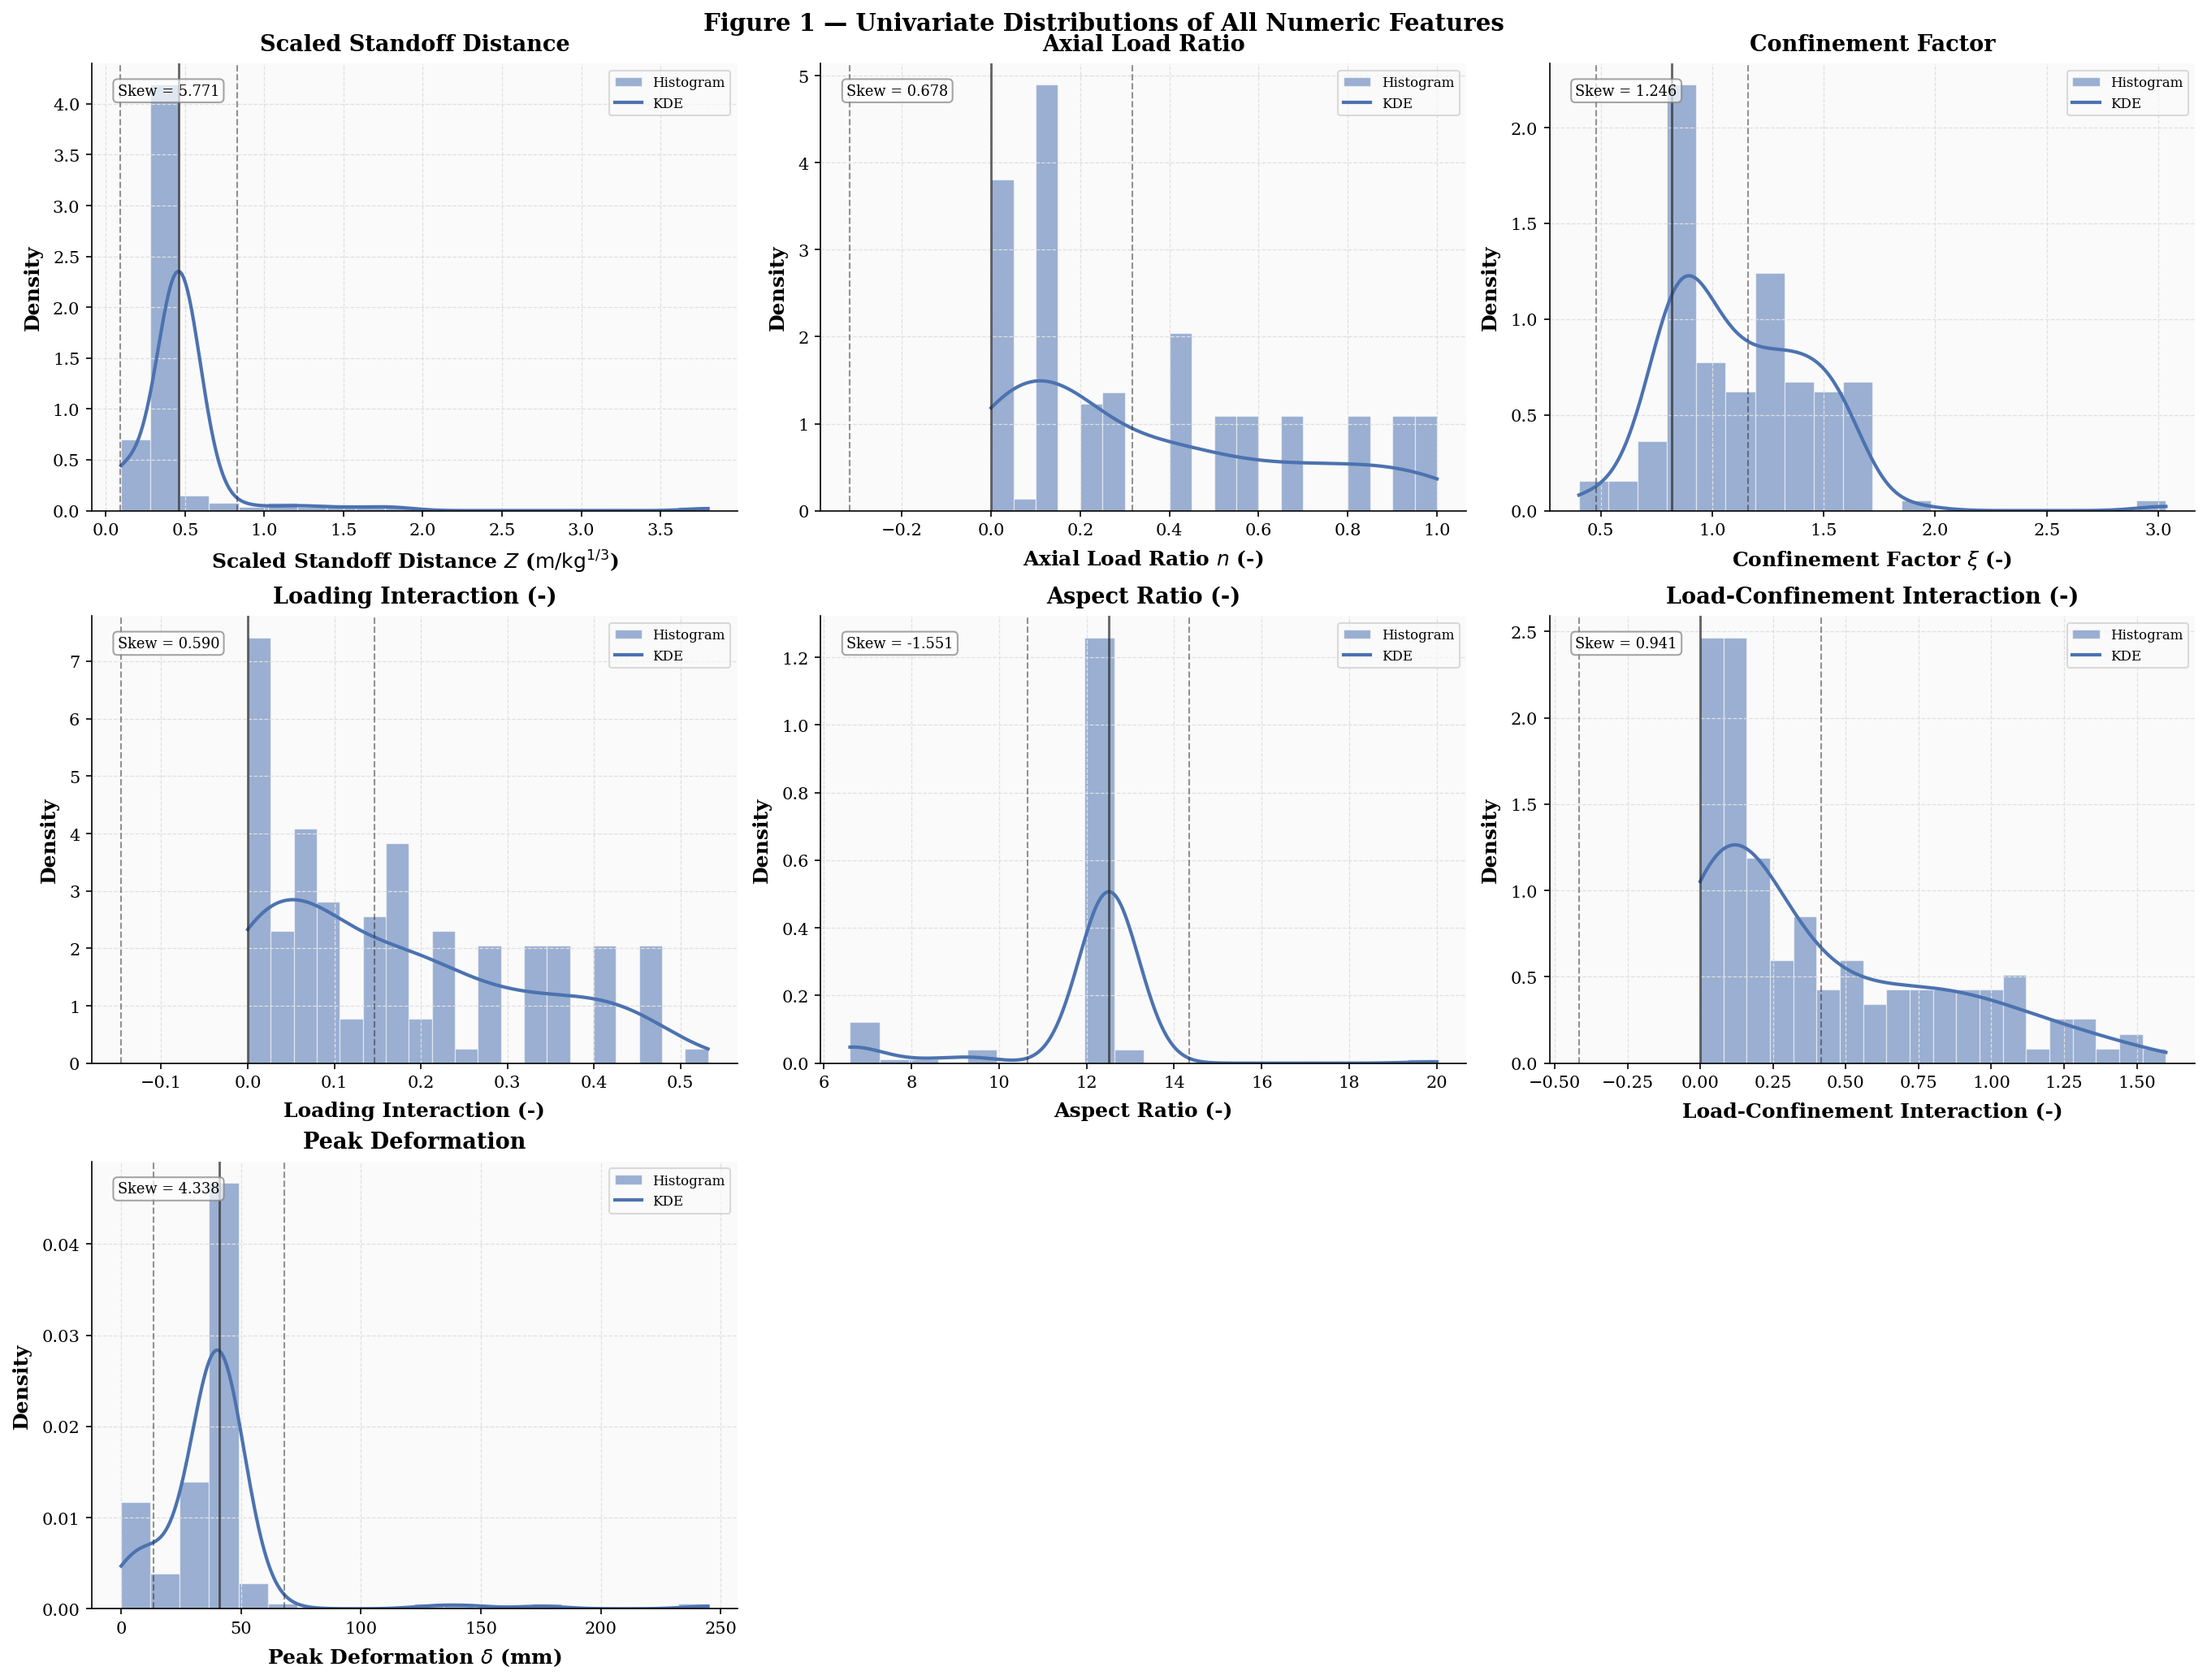

✓ Figure 1 saved.


In [37]:
# ==========================================
# 7. HISTOGRAM PLOTS (training set)
# ==========================================

n_cols = 3
n_rows = int(np.ceil(len(NUMERIC_FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(6 * n_cols, 4.5 * n_rows),
                         constrained_layout=True)
axes = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    ax  = axes[i]
    col = df[feat].dropna()

    ax.hist(col, bins=20, color="#4C72B0", alpha=0.55,
            edgecolor="white", linewidth=0.6, density=True, label="Histogram")

    # KDE
    kde_x = np.linspace(col.min(), col.max(), 300)
    kde   = stats.gaussian_kde(col)
    ax.plot(kde_x, kde(kde_x), color="#4C72B0", lw=2.0, label="KDE")

    # Normal fit
    mu, sigma = col.mode().iloc[0], col.std()
    # ax.plot(kde_x, stats.norm.pdf(kde_x, mu, sigma),
    #         color="#DD4444", lw=1.6, ls="--", label="Normal fit")

    # Mean / ±1σ lines
    ax.axvline(mu,          color="#2B2B2B", lw=1.4, ls="-",  alpha=0.7)
    ax.axvline(mu - sigma,  color="#2B2B2B", lw=1.0, ls="--", alpha=0.5)
    ax.axvline(mu + sigma,  color="#2B2B2B", lw=1.0, ls="--", alpha=0.5)

    # ax.set_xlim(mu - 3*sigma, mu + 3*sigma)

    ax.set_xlabel(labels.get(feat, feat), labelpad=6)
    ax.set_ylabel("Density", labelpad=6)
    ax.set_title(f"{labels.get(feat, feat).split('$')[0].strip()}", pad=8)
    ax.legend(loc="upper right", fontsize=8)

    # Skewness annotation
    ax.text(0.04, 0.93, f"Skew = {col.skew():.3f}",
            transform=ax.transAxes, fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.7))

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Figure 1 — Univariate Distributions of All Numeric Features",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("fig1_histograms.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Figure 1 saved.")


---
## 7. Box Plots and Violin Plots (Training Set)

Box plots reveal outliers and quartile structure; violin plots add the full density estimate.
Both are stratified by the two categorical variables — **cross-section shape** and
**end-support conditions (Rx2)** — to expose group-level differences.


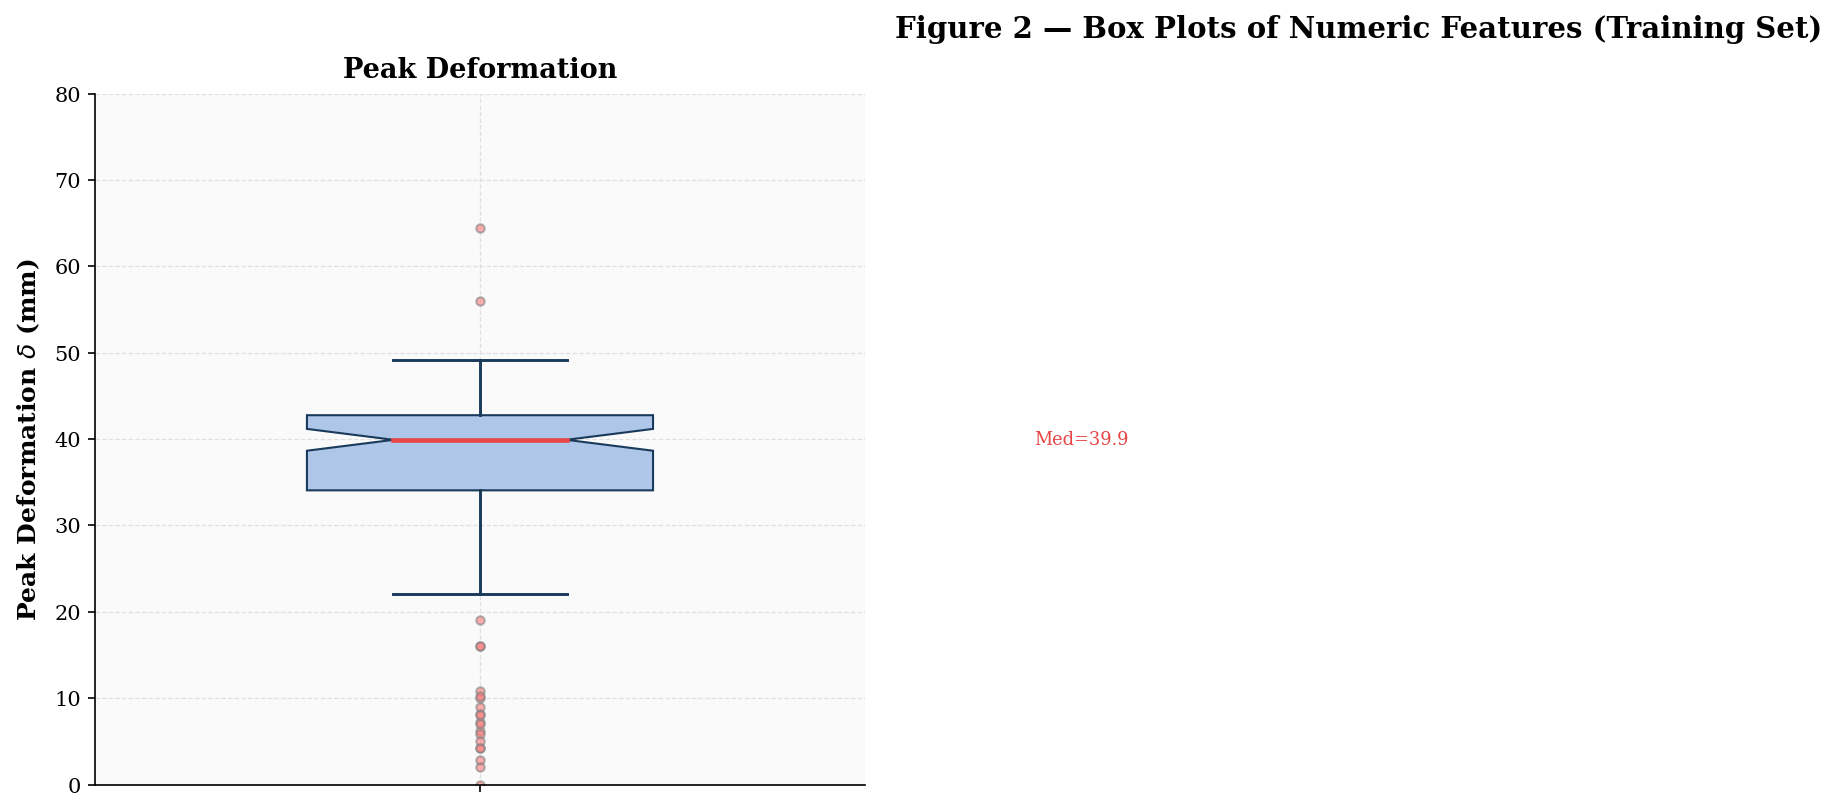

✓ Figure 2 saved.


In [17]:
# ==========================================
# 8a. BOX PLOTS — numeric features
# ==========================================

plot_feats = [TARGET]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()

for i, feat in enumerate(plot_feats):
    ax = axes[i]
    bp = ax.boxplot(df_train[feat].dropna(),
                    patch_artist=True,
                    notch=True,
                    widths=0.45,
                    boxprops    =dict(facecolor="#AEC6E8", color="#1A3A5C"),
                    medianprops =dict(color="#E84545",     linewidth=2.2),
                    whiskerprops=dict(color="#1A3A5C",     linewidth=1.4),
                    capprops    =dict(color="#1A3A5C",     linewidth=1.4),
                    flierprops  =dict(marker="o", markerfacecolor="#FF7C7C",
                                      markeredgecolor="grey", markersize=4, alpha=0.6))

    ax.set_ylim(0, 80)
    
    ax.set_xticklabels([""])
    ax.set_ylabel(labels.get(feat, feat), labelpad=6)
    ax.set_title(labels.get(feat, feat).split("$")[0].strip(), pad=8)

    med = df_train[feat].median()
    ax.text(1.22, med, f"Med={med:.3g}",
            va="center", ha="left", fontsize=8.5, color="#E84545",
            transform=ax.get_yaxis_transform())

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Figure 2 — Box Plots of Numeric Features (Training Set)",
             fontsize=14, fontweight="bold")
plt.savefig("fig2_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Figure 2 saved.")


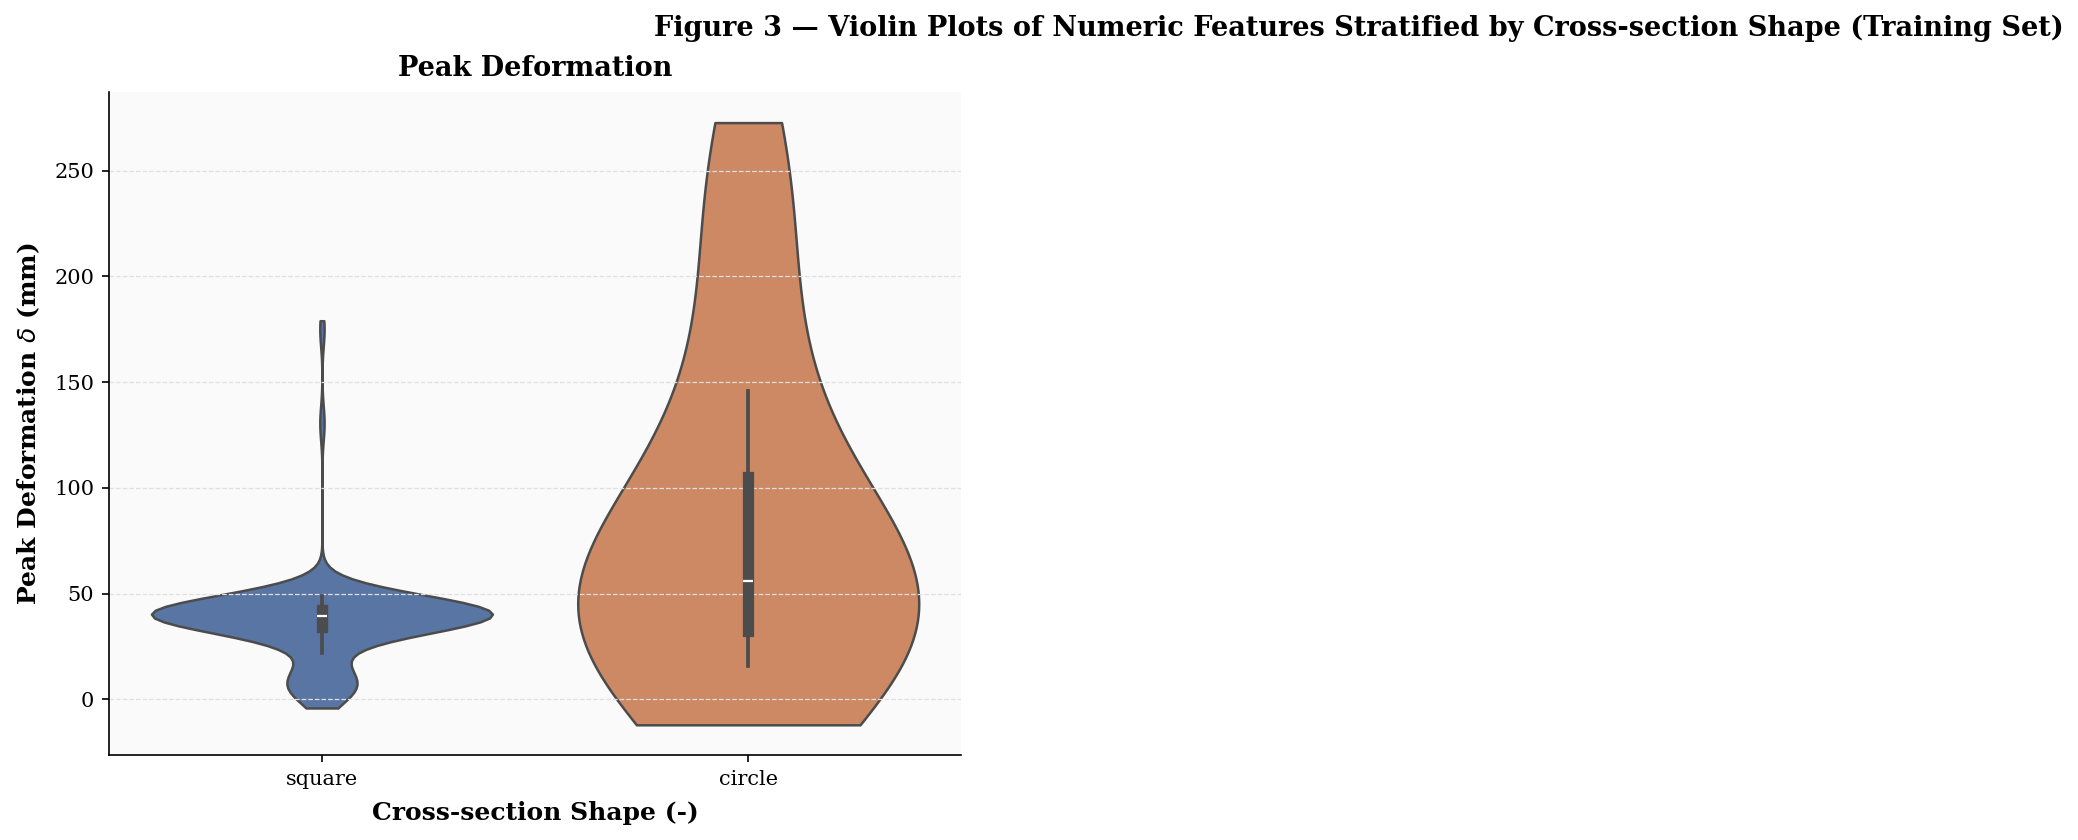

✓ Figure 3 saved.


In [18]:
# ==========================================
# 8b. VIOLIN PLOTS stratified by cross-section shape
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()

for i, feat in enumerate(plot_feats):
    ax = axes[i]
    sns.violinplot(
        data=df_train, x='shape of the cross section', y=feat,
        palette={"square": "#4C72B0", "circle": "#DD8452"},
        inner="box", cut=0.5, linewidth=1.2, ax=ax
    )
    ax.set_xlabel(labels['shape of the cross section'], labelpad=6)
    ax.set_ylabel(labels.get(feat, feat), labelpad=6)
    ax.set_title(labels.get(feat, feat).split("$")[0].strip(), pad=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Figure 3 — Violin Plots of Numeric Features Stratified by Cross-section Shape (Training Set)",
    fontsize=13, fontweight="bold"
)
plt.savefig("fig3_violin_shape.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Figure 3 saved.")


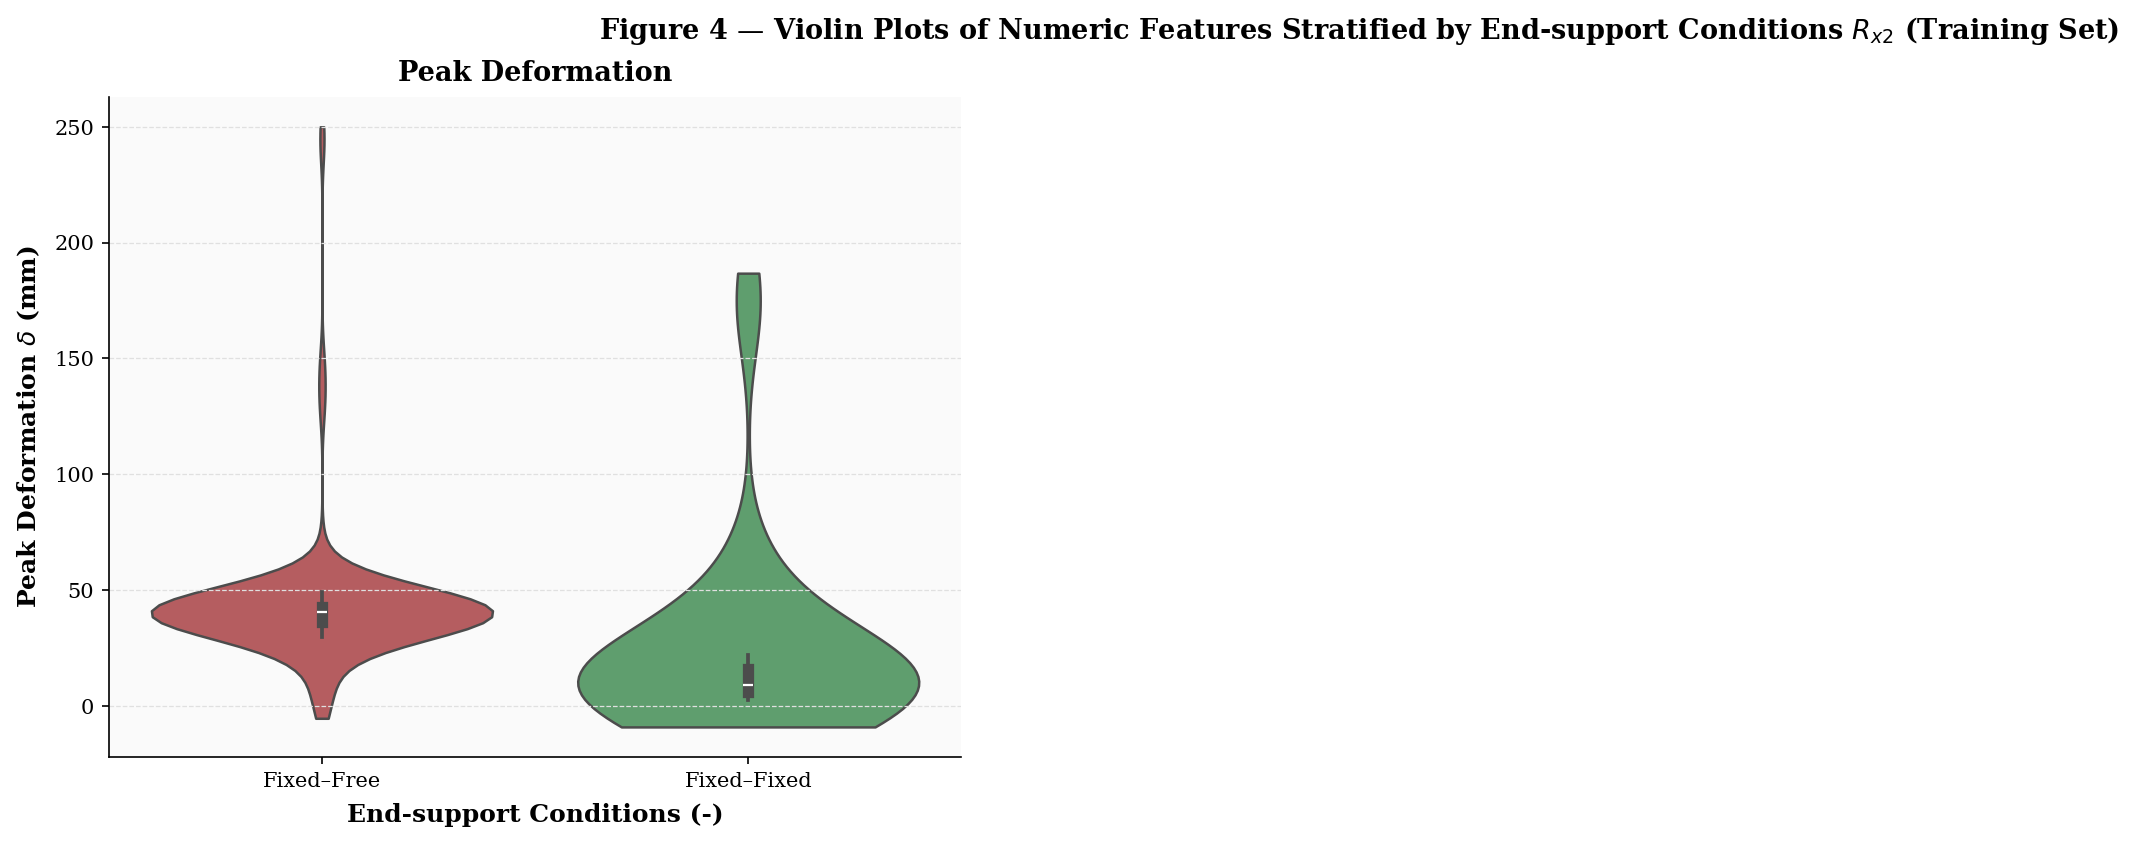

✓ Figure 4 saved.


In [19]:
# ==========================================
# 8c. VIOLIN PLOTS stratified by Rx2 (end-support conditions)
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()

rx2_labels = {0: "Fixed–Fixed", 1: "Fixed–Free"}

df_train_v = df_train.copy()
df_train_v['Rx2_label'] = df_train_v['Rx2'].map(rx2_labels)

for i, feat in enumerate(plot_feats):
    ax = axes[i]
    sns.violinplot(
        data=df_train_v, x='Rx2_label', y=feat,
        palette={"Fixed–Fixed": "#55A868", "Fixed–Free": "#C44E52"},
        inner="box", cut=0.5, linewidth=1.2, ax=ax
    )
    ax.set_xlabel(labels['Rx2'], labelpad=6)
    ax.set_ylabel(labels.get(feat, feat), labelpad=6)
    ax.set_title(labels.get(feat, feat).split("$")[0].strip(), pad=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Figure 4 — Violin Plots of Numeric Features Stratified by End-support Conditions $R_{x2}$ (Training Set)",
    fontsize=13, fontweight="bold"
)
plt.savefig("fig4_violin_rx2.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Figure 4 saved.")


---
## 8. Correlation Analysis

### 8.1 Pearson Correlation (Linear)
Pearson's $r$ measures the strength of *linear* association between pairs of variables.

### 8.2 Spearman Correlation (Rank-based)
Spearman's $\rho$ captures monotonic (not necessarily linear) associations and is robust to
outliers.  Both matrices are reported alongside numeric tables with two-sided *p*-values.


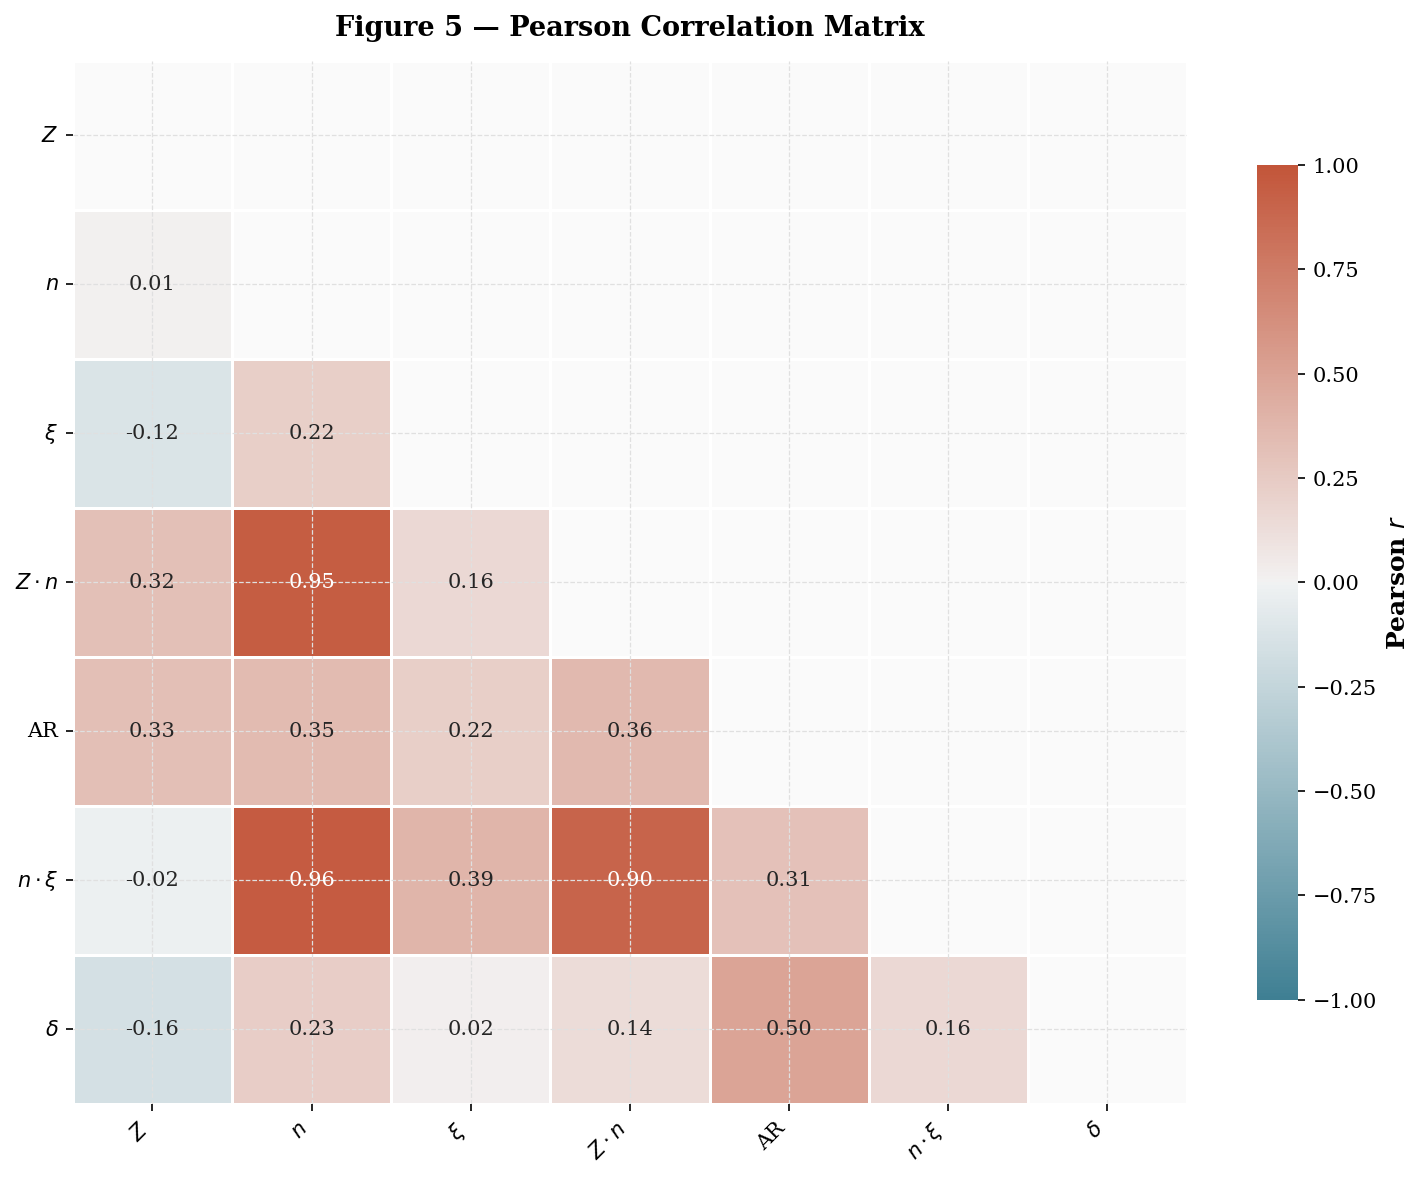

✓ Figure 5 saved.


In [28]:
# ==========================================
# 9a. PEARSON CORRELATION MATRIX
# ==========================================

corr_feats = NUMERIC_FEATURES   # includes target

def compute_corr_with_pval(data, cols, method="pearson"):
    n   = len(cols)
    r   = np.zeros((n, n))
    p   = np.zeros((n, n))
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                r[i, j], p[i, j] = 1.0, 0.0
            else:
                s1, s2 = data[c1].dropna(), data[c2].dropna()
                idx    = s1.index.intersection(s2.index)
                if method == "pearson":
                    rv, pv = pearsonr(s1[idx], s2[idx])
                else:
                    rv, pv = spearmanr(s1[idx], s2[idx])
                r[i, j] = rv
                p[i, j] = pv
    r_df = pd.DataFrame(r, index=cols, columns=cols)
    p_df = pd.DataFrame(p, index=cols, columns=cols)
    return r_df, p_df

pearson_r, pearson_p = compute_corr_with_pval(df, corr_feats, "pearson")

short_labels = {
    'scaled stand off distance'        : r'$Z$',
    'axial load ratio'                 : r'$n$',
    'confinement'                      : r'$\xi$',
    'loading_interaction'              : r'$Z \cdot n$',
    'aspect_ratio'                     : r'AR',
    'load_confinement_interaction'     : r'$n \cdot \xi$',
    'peak deformation (mm)'            : r'$\delta$',
}

sl = [short_labels.get(c, c) for c in corr_feats]

mask = np.triu(np.ones_like(pearson_r, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(pearson_r, mask=mask, cmap=cmap, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 10},
            linewidths=0.5, linecolor="white",
            xticklabels=sl, yticklabels=sl,
            cbar_kws={"label": "Pearson $r$", "shrink": 0.8}, ax=ax)
ax.set_title("Figure 5 — Pearson Correlation Matrix", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("fig5_pearson_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Figure 5 saved.")


In [29]:
# ── Pearson correlation table ───────────────────────────────────────────────
pearson_tgt = pd.DataFrame({
    "Feature"          : corr_feats,
    "Pearson r"        : [pearson_r.loc[f, TARGET] for f in corr_feats],
    "p-value"          : [pearson_p.loc[f, TARGET] for f in corr_feats],
    "|r|"              : [abs(pearson_r.loc[f, TARGET]) for f in corr_feats],
    "Significant (α=0.05)" : [pearson_p.loc[f, TARGET] < 0.05 for f in corr_feats],
}).set_index("Feature").sort_values("|r|", ascending=False)

display(pearson_tgt.round(4).style
        .set_caption(f"Table 4 — Pearson correlation with target: {TARGET}")
        .set_table_styles([{"selector": "caption",
                            "props": [("font-size", "13px"),
                                      ("font-weight", "bold"),
                                      ("text-align", "left")]}])
        .background_gradient(cmap="RdBu_r", subset=["Pearson r"], vmin=-1, vmax=1)
        .format({"Pearson r": "{:.4f}", "p-value": "{:.4f}", "|r|": "{:.4f}"}))


,Pearson r,p-value,|r|,Significant (α=0.05)
Feature,,,,
peak deformation (mm),1.0000,0.0000,1.0000,True
aspect_ratio,0.4993,0.0000,0.4993,True
axial load ratio,0.2319,0.0047,0.2319,True
scaled stand off distance,-0.1579,0.0561,0.1579,False
load_confinement_interaction,0.1564,0.0585,0.1564,False
loading_interaction,0.1397,0.0914,0.1397,False
confinement,0.0169,0.8393,0.0169,False


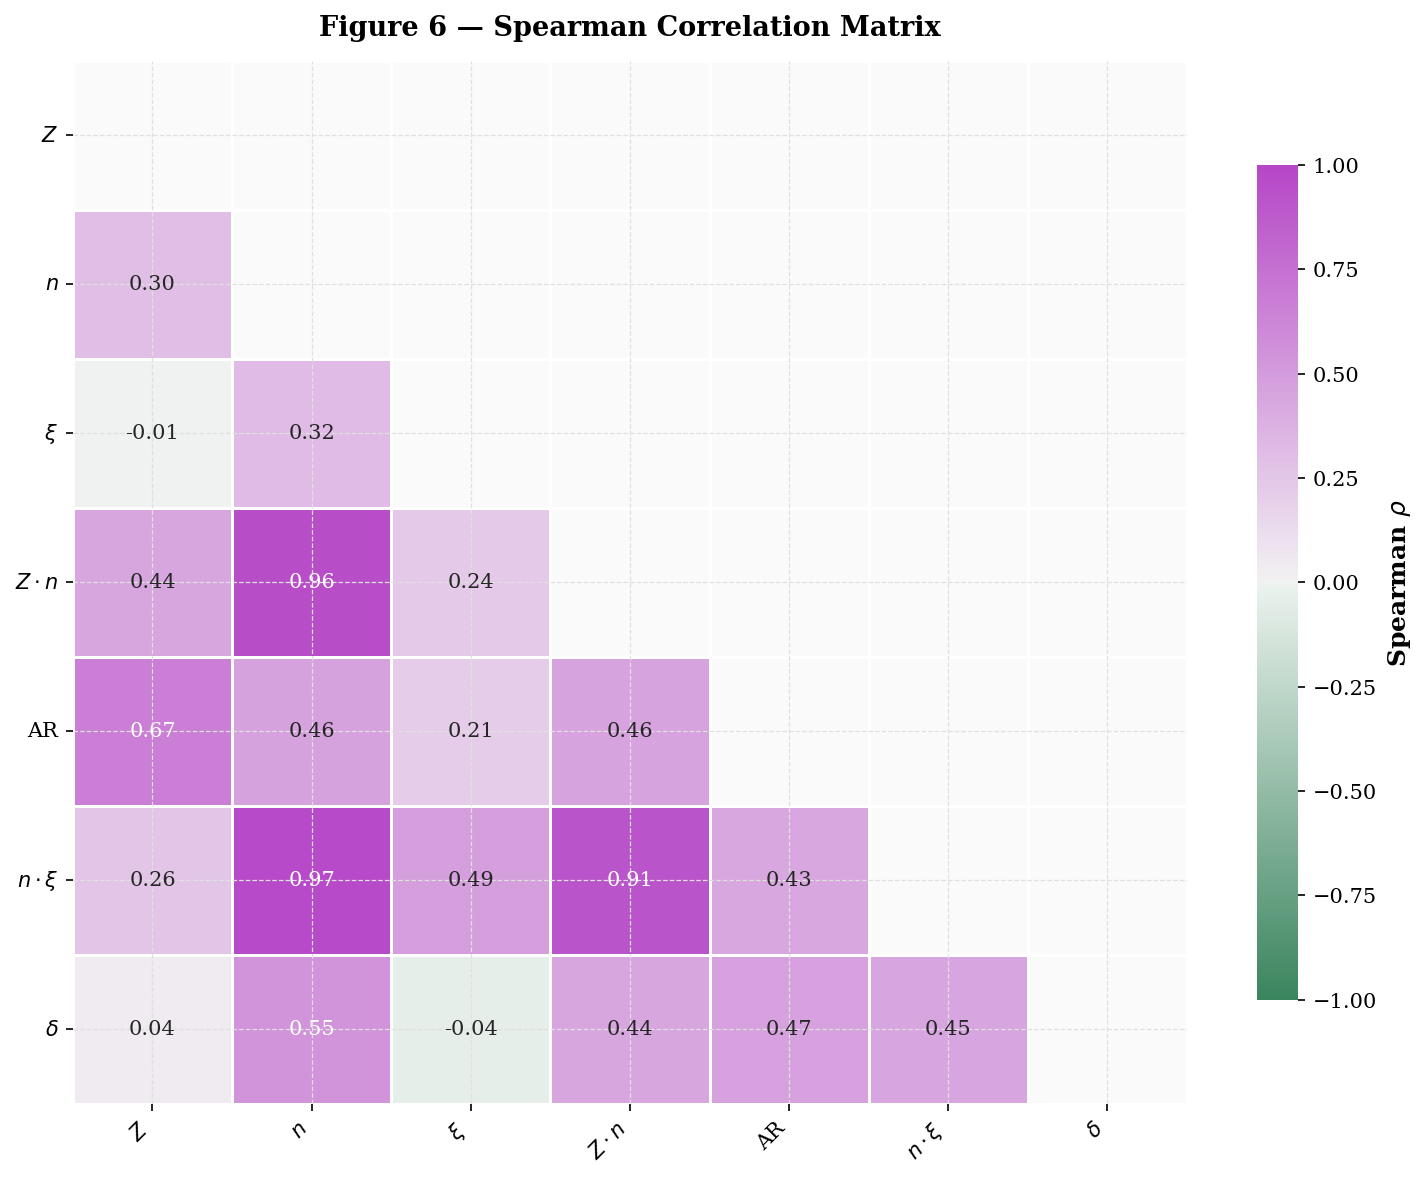

✓ Figure 6 saved.


In [30]:
# ==========================================
# 9b. SPEARMAN CORRELATION MATRIX
# ==========================================

spearman_r, spearman_p = compute_corr_with_pval(df, corr_feats, "spearman")

fig, ax = plt.subplots(figsize=(10, 8))
cmap2 = sns.diverging_palette(145, 300, as_cmap=True)
sns.heatmap(spearman_r, mask=mask, cmap=cmap2, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 10},
            linewidths=0.5, linecolor="white",
            xticklabels=sl, yticklabels=sl,
            cbar_kws={"label": r"Spearman $\rho$", "shrink": 0.8}, ax=ax)
ax.set_title(r"Figure 6 — Spearman Correlation Matrix", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("fig6_spearman_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Figure 6 saved.")


In [31]:
# ── Spearman correlation table ──────────────────────────────────────────────
spearman_tgt = pd.DataFrame({
    "Feature"              : corr_feats,
    "Spearman ρ"           : [spearman_r.loc[f, TARGET] for f in corr_feats],
    "p-value"              : [spearman_p.loc[f, TARGET] for f in corr_feats],
    "|ρ|"                  : [abs(spearman_r.loc[f, TARGET]) for f in corr_feats],
    "Significant (α=0.05)" : [spearman_p.loc[f, TARGET] < 0.05 for f in corr_feats],
}).set_index("Feature").sort_values("|ρ|", ascending=False)

display(spearman_tgt.round(4).style
        .set_caption(f"Table 5 — Spearman correlation with target: {TARGET}")
        .set_table_styles([{"selector": "caption",
                            "props": [("font-size", "13px"),
                                      ("font-weight", "bold"),
                                      ("text-align", "left")]}])
        .background_gradient(cmap="PRGn", subset=["Spearman ρ"], vmin=-1, vmax=1)
        .format({"Spearman ρ": "{:.4f}", "p-value": "{:.4f}", "|ρ|": "{:.4f}"}))


,Spearman ρ,p-value,|ρ|,Significant (α=0.05)
Feature,,,,
peak deformation (mm),1.0000,0.0000,1.0000,True
axial load ratio,0.5468,0.0000,0.5468,True
aspect_ratio,0.4697,0.0000,0.4697,True
load_confinement_interaction,0.4488,0.0000,0.4488,True
loading_interaction,0.4427,0.0000,0.4427,True
confinement,-0.0450,0.5886,0.0450,False
scaled stand off distance,0.0417,0.6157,0.0417,False


---
## 9. Pair Plot Analysis

A pair plot (scatter-matrix) visualises all pairwise relationships between features.
The diagonal shows KDE estimates; off-diagonal panels show bivariate scatter plots
coloured by **cross-section shape** to expose group separation in feature space.


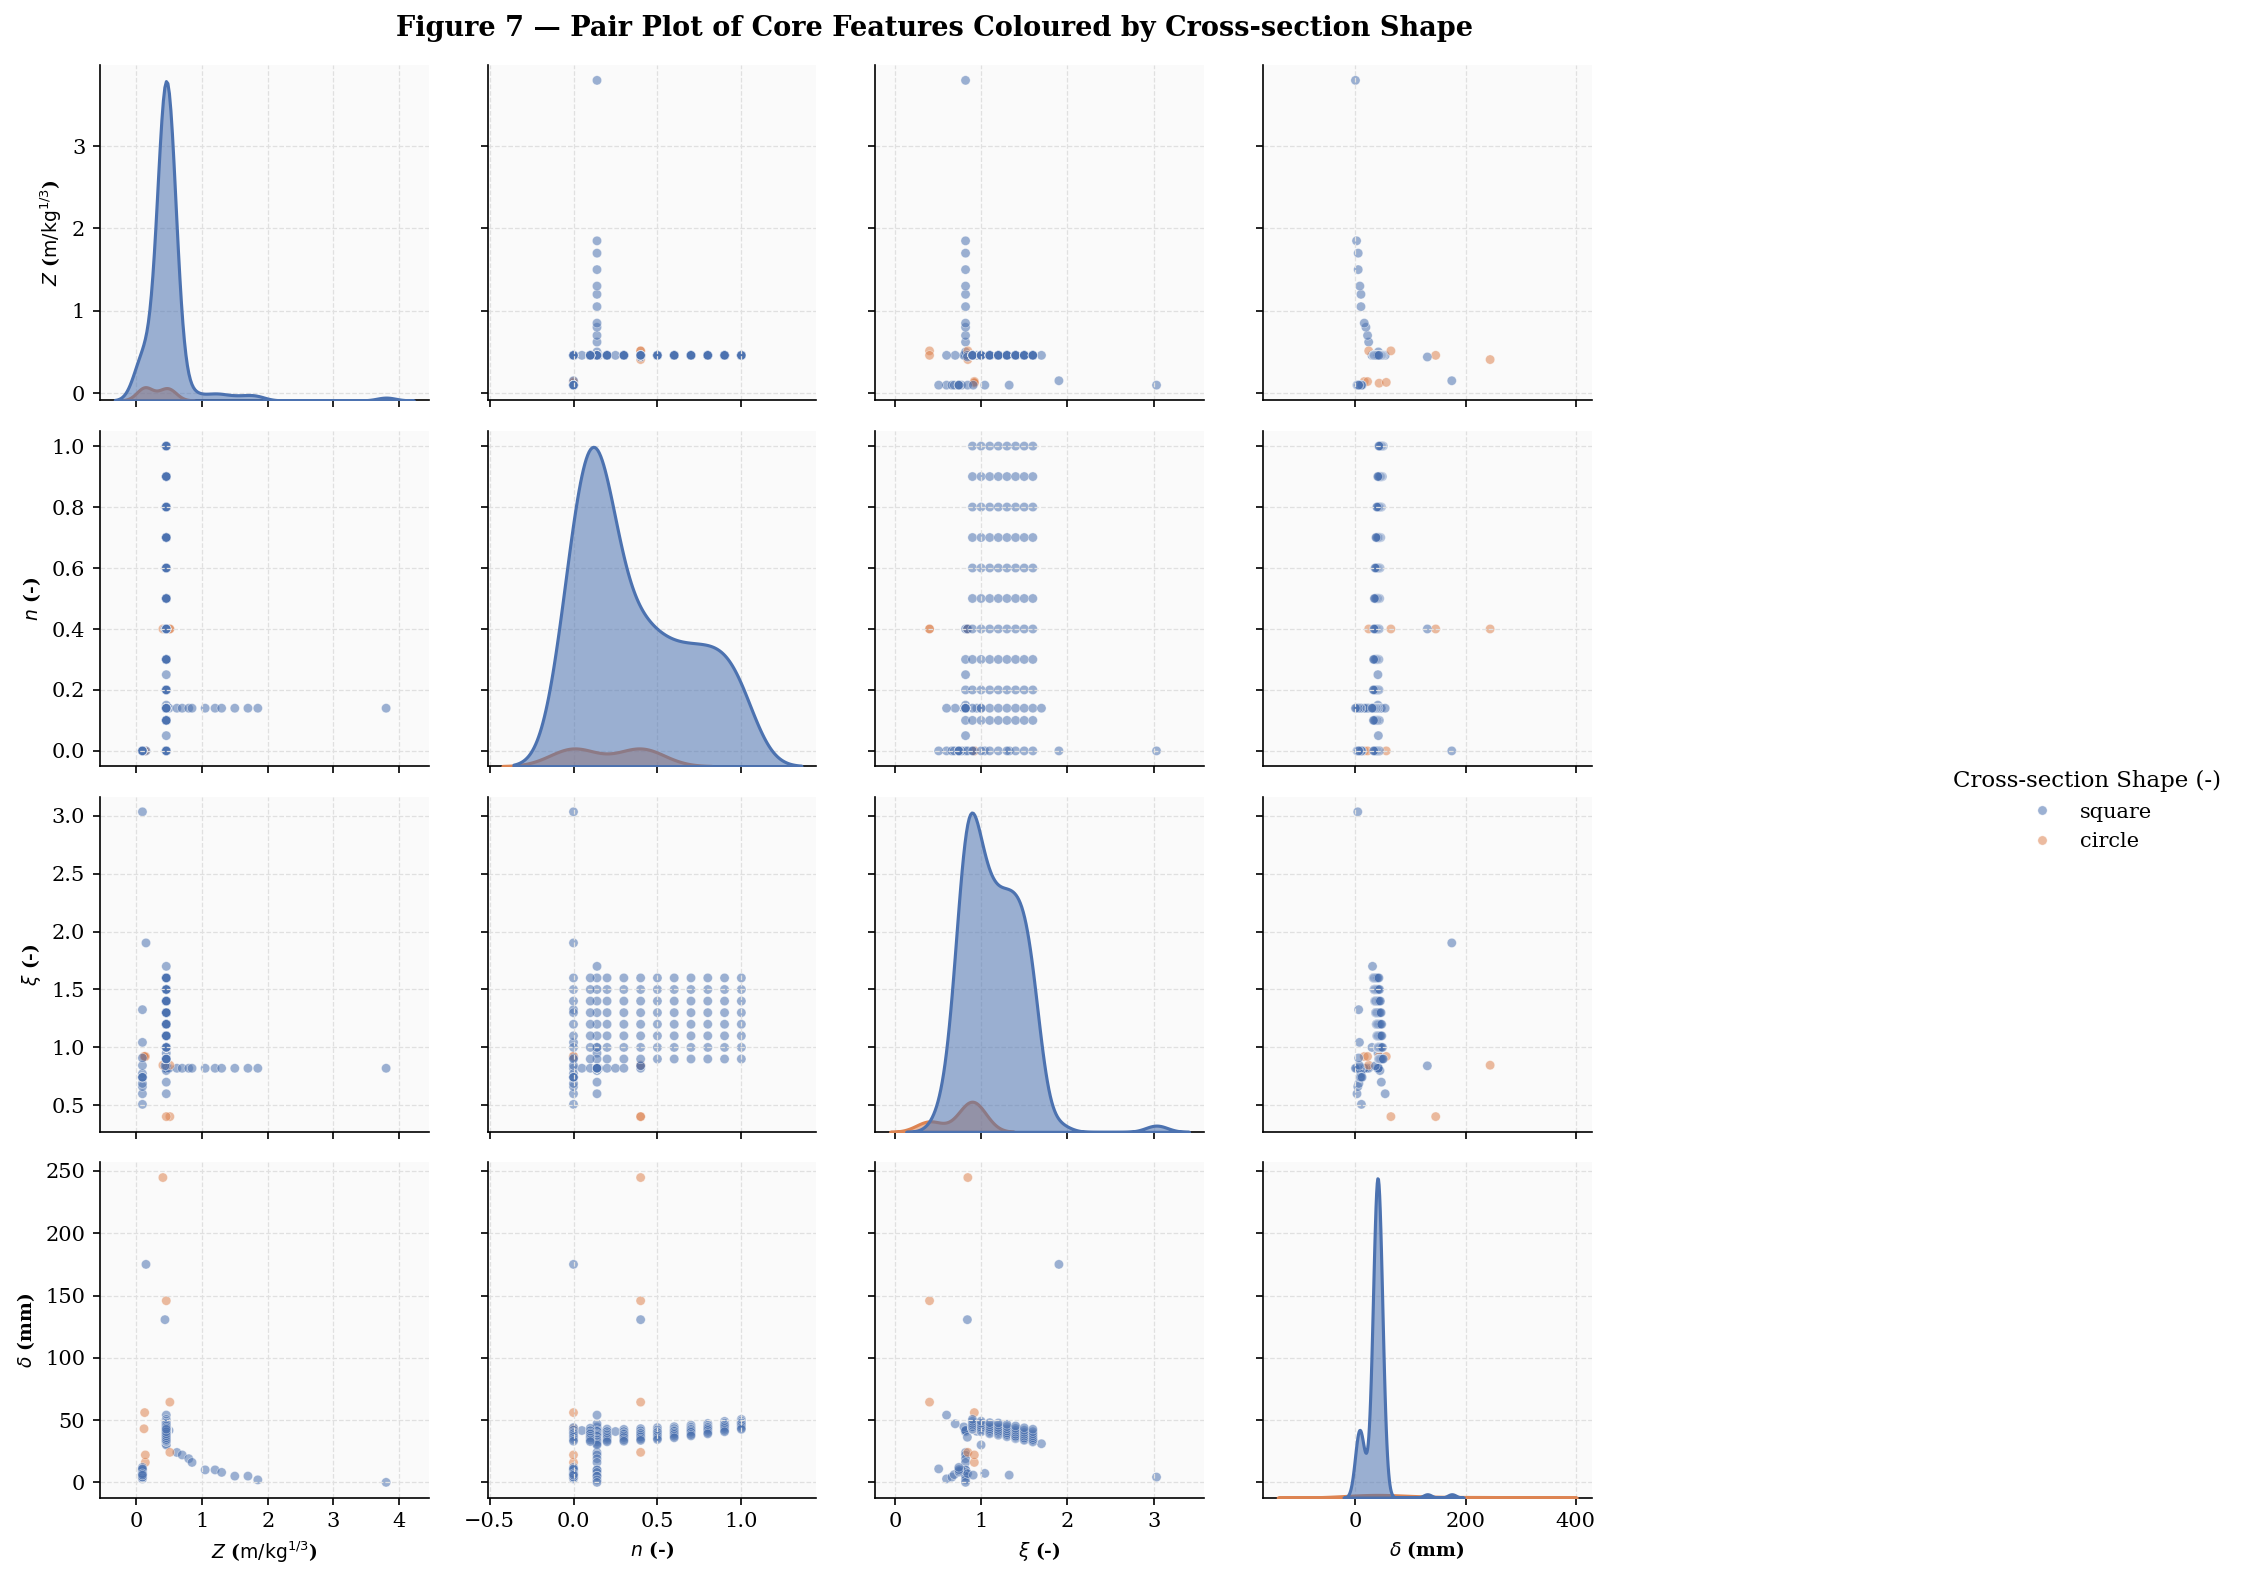

✓ Figure 7 saved.


In [32]:
# ==========================================
# 10. PAIR PLOT ANALYSIS
# ==========================================

pair_cols = ['scaled stand off distance', 'axial load ratio', 'confinement',
             'peak deformation (mm)', 'shape of the cross section']

pp_data = df[pair_cols].copy()

g = sns.PairGrid(pp_data,
                 hue='shape of the cross section',
                 palette={"square": "#4C72B0", "circle": "#DD8452"},
                 diag_sharey=False,
                 height=2.6, aspect=1.05)

g.map_diag(sns.kdeplot, fill=True, linewidth=1.5, alpha=0.55)
g.map_offdiag(sns.scatterplot, alpha=0.55, s=20, edgecolor="white", linewidth=0.3)
g.add_legend(title=labels['shape of the cross section'],
             bbox_to_anchor=(1.02, 0.5), loc="center left")

# Apply formal axis labels
rename = {
    'scaled stand off distance' : r'$Z$ ($\mathrm{m/kg}^{1/3}$)',
    'axial load ratio'          : r'$n$ (-)',
    'confinement'               : r'$\xi$ (-)',
    'peak deformation (mm)'     : r'$\delta$ (mm)',
}
for ax in g.axes.flatten():
    if ax is not None:
        xl = ax.get_xlabel()
        yl = ax.get_ylabel()
        if xl in rename: ax.set_xlabel(rename[xl], fontsize=9)
        if yl in rename: ax.set_ylabel(rename[yl], fontsize=9)

g.figure.suptitle(
    "Figure 7 — Pair Plot of Core Features Coloured by Cross-section Shape",
    y=1.01, fontsize=13, fontweight="bold"
)
plt.savefig("fig7_pairplot.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Figure 7 saved.")


---
## 10. Target Variable Analysis

A detailed inspection of the target variable — **Peak Deformation** $\delta$ — including
distributional overlay, Q–Q plot, and log-transformed variant to assess suitability
for regression modelling.


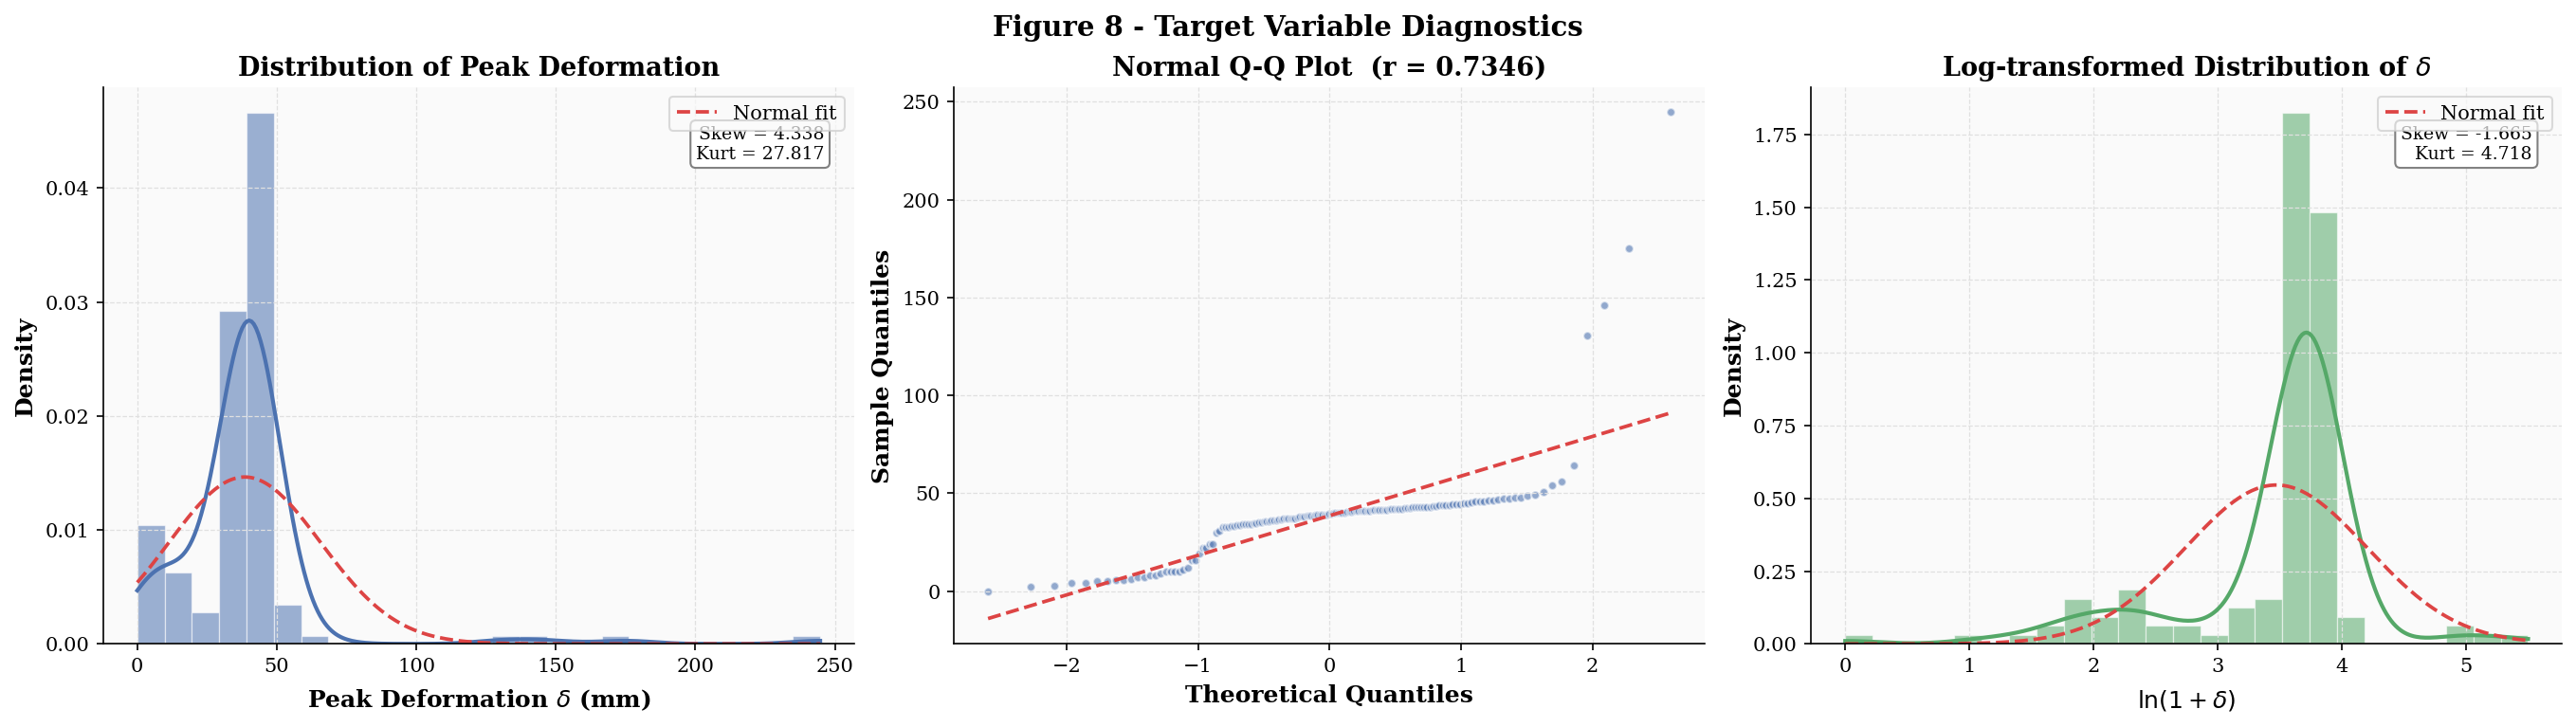

Figure 8 saved.


In [34]:
# ==========================================
# 11. TARGET VARIABLE DIAGNOSTICS
# ==========================================

tgt = df[TARGET].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# 11a. Histogram + KDE
ax = axes[0]
ax.hist(tgt, bins=25, color="#4C72B0", alpha=0.55,
        edgecolor="white", linewidth=0.6, density=True)
kde_x = np.linspace(tgt.min(), tgt.max(), 300)
ax.plot(kde_x, stats.gaussian_kde(tgt)(kde_x), "#4C72B0", lw=2)
ax.plot(kde_x, stats.norm.pdf(kde_x, tgt.mean(), tgt.std()),
        "#DD4444", lw=1.8, ls="--", label="Normal fit")
ax.set_xlabel(labels[TARGET], labelpad=6)
ax.set_ylabel("Density")
ax.set_title("Distribution of Peak Deformation")
ax.legend()
skew_str = "Skew = {:.3f}\nKurt = {:.3f}".format(tgt.skew(), tgt.kurtosis())
ax.text(0.96, 0.93, skew_str, transform=ax.transAxes, ha="right", va="top",
        fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey"))

# 11b. Q-Q plot
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(tgt, dist="norm")
ax.scatter(osm, osr, s=18, alpha=0.6, color="#4C72B0", edgecolors="white")
ax.plot(osm, slope * np.array(osm) + intercept, "#DD4444", lw=1.8, ls="--")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
ax.set_title("Normal Q-Q Plot  (r = {:.4f})".format(r))

# 11c. Log-transformed histogram
ax = axes[2]
log_tgt = np.log1p(tgt)
ax.hist(log_tgt, bins=25, color="#55A868", alpha=0.55,
        edgecolor="white", linewidth=0.6, density=True)
kde_lx = np.linspace(log_tgt.min(), log_tgt.max(), 300)
ax.plot(kde_lx, stats.gaussian_kde(log_tgt)(kde_lx), "#55A868", lw=2)
ax.plot(kde_lx, stats.norm.pdf(kde_lx, log_tgt.mean(), log_tgt.std()),
        "#DD4444", lw=1.8, ls="--", label="Normal fit")
ax.set_xlabel(r"$\ln(1 + \delta)$", labelpad=6)
ax.set_ylabel("Density")
ax.set_title(r"Log-transformed Distribution of $\delta$")
ax.legend()
log_skew_str = "Skew = {:.3f}\nKurt = {:.3f}".format(log_tgt.skew(), log_tgt.kurtosis())
ax.text(0.96, 0.93, log_skew_str, transform=ax.transAxes, ha="right", va="top",
        fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey"))

fig.suptitle("Figure 8 - Target Variable Diagnostics",
             fontsize=14, fontweight="bold")
plt.savefig("fig8_target_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 8 saved.")


---
## 11. Normality Analysis — Q–Q Plots & Shapiro–Wilk Test

The Q–Q plot (quantile–quantile plot) compares the empirical quantile structure of each
feature against the theoretical quantiles of a standard normal distribution.
Departures from the 45° reference line indicate non-normality.

Each feature panel contains:
- **Left** — Q–Q scatter with the normal reference line (dashed red) and deviation
  shading (orange fill), annotated with the coefficient of determination $R^2$ of the
  line fit and Shapiro–Wilk statistic $W$.
- **Right** — Standardised residuals from the Q–Q reference line, revealing systematic
  bias (skewness) or heavy-tail behaviour (kurtosis).

> **Subset used:** Square cross-section specimens (`random_state = 42`).


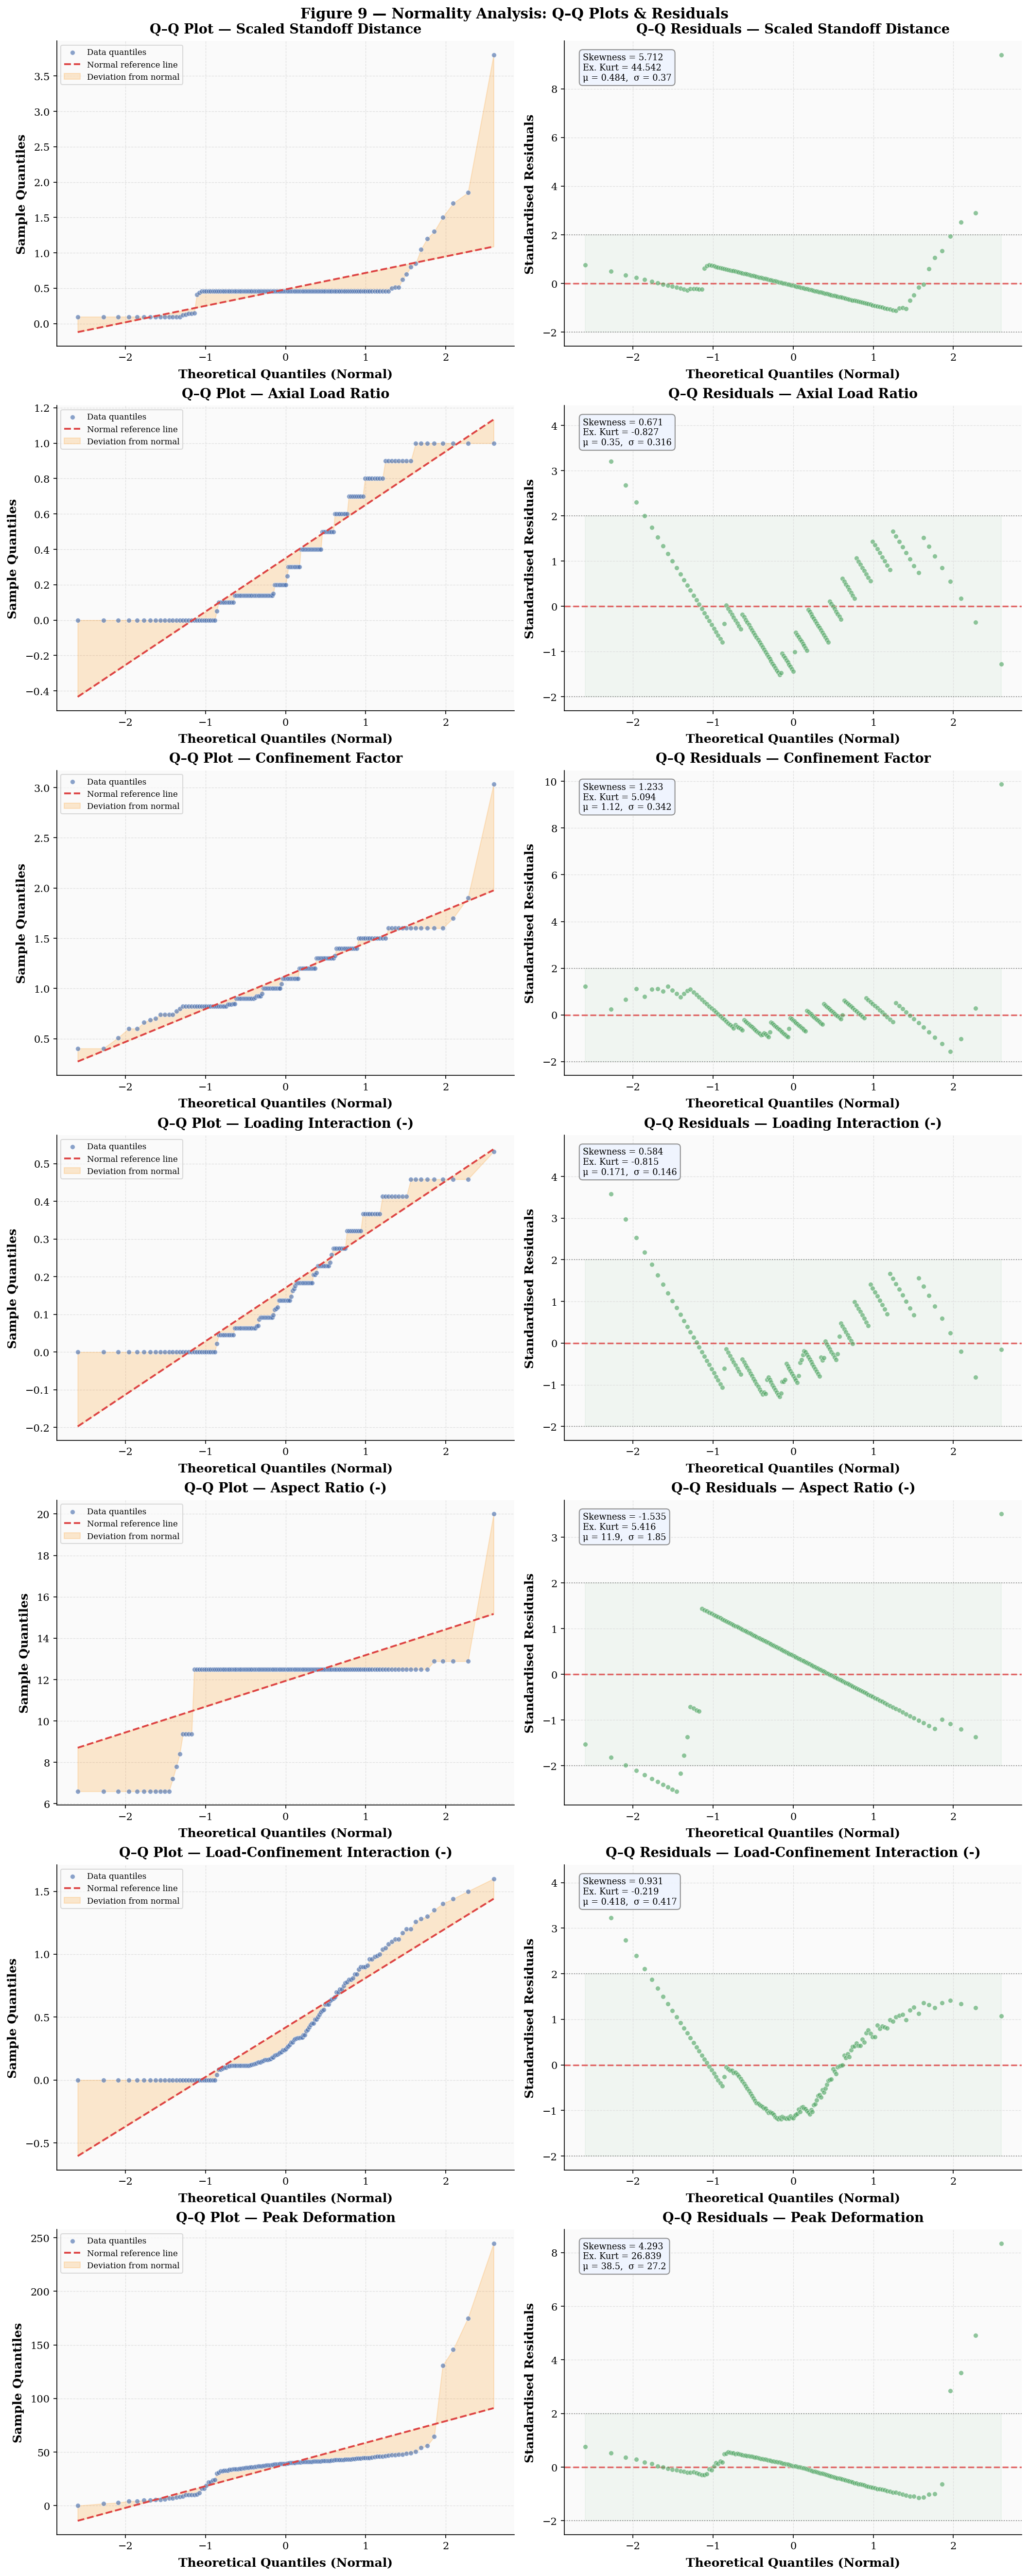

Figure 9 saved.


In [38]:
# ==========================================
# 12. NORMALITY ANALYSIS — QQ PLOTS
# ==========================================

def create_normality_analysis(df, numerical_cols):
    plot_cols = numerical_cols[:8]
    n_cols    = len(plot_cols)

    fig, axes = plt.subplots(n_cols, 2,
                             figsize=(14, 5 * n_cols),
                             constrained_layout=True)

    for i, col in enumerate(plot_cols):
        subset = df[col].dropna()

        # ── Statistics ──────────────────────────────────────────────────────
        sw_stat, sw_p = stats.shapiro(subset)
        skewness      = stats.skew(subset)
        kurt          = stats.kurtosis(subset)   # excess kurtosis
        mean_val      = subset.mean()
        std_val       = subset.std()
        is_normal     = sw_p > 0.05

        # ── LEFT: QQ Plot ────────────────────────────────────────────────────
        ax_qq = axes[i, 0]
        (osm, osr), (slope, intercept, r) = stats.probplot(subset, dist="norm")

        ax_qq.scatter(osm, osr,
                      alpha=0.65, color="#4C72B0", s=22,
                      edgecolors="white", linewidths=0.4,
                      label="Data quantiles", zorder=3)

        x_line = np.linspace(min(osm), max(osm), 200)
        ax_qq.plot(x_line, slope * x_line + intercept,
                   color="#DD4444", linewidth=1.8, linestyle="--",
                   label="Normal reference line", zorder=4)

        y_ref = slope * np.array(osm) + intercept
        ax_qq.fill_between(osm, osr, y_ref,
                           alpha=0.18, color="#FF8C00",
                           label="Deviation from normal", zorder=2)

        ax_qq.set_xlabel("Theoretical Quantiles (Normal)", labelpad=6)
        ax_qq.set_ylabel("Sample Quantiles", labelpad=6)
        feat_label = labels.get(col, col).split("$")[0].strip()
        ax_qq.set_title(f"Q–Q Plot — {feat_label}", pad=8)
        ax_qq.legend(fontsize=8, loc="upper left")

        # R² + Shapiro-Wilk annotation
        normal_tag = "Normal" if is_normal else "Non-normal"
        # annot_text = (
        #     f"$R^2$ = {r**2:.4f}\n"
        #     f"$W$  = {sw_stat:.4f}\n"
        #     f"$p$  = {sw_p:.4f}\n"
        #     f"{normal_tag} (\u03b1 = 0.05)"
        # )
        # ax_qq.text(0.04, 0.96, annot_text,
        #            transform=ax_qq.transAxes,
        #            fontsize=8.5, va="top", ha="left",
        #            bbox=dict(boxstyle="round,pad=0.4",
        #                      facecolor="lightyellow",
        #                      edgecolor="grey", alpha=0.85))

        # ── RIGHT: Standardised Q–Q Residuals ───────────────────────────────
        ax_res = axes[i, 1]
        residuals = np.array(osr) - (slope * np.array(osm) + intercept)
        res_std   = residuals / (residuals.std() if residuals.std() != 0 else 1)

        ax_res.scatter(osm, res_std,
                       alpha=0.65, color="#55A868", s=22,
                       edgecolors="white", linewidths=0.4, zorder=3)
        ax_res.axhline(0, color="#DD4444", lw=1.6, ls="--", alpha=0.8)
        ax_res.axhline( 2, color="#2B2B2B", lw=0.9, ls=":", alpha=0.5)
        ax_res.axhline(-2, color="#2B2B2B", lw=0.9, ls=":", alpha=0.5)
        ax_res.fill_between(osm, -2, 2, alpha=0.06, color="#55A868")

        ax_res.set_xlabel("Theoretical Quantiles (Normal)", labelpad=6)
        ax_res.set_ylabel("Standardised Residuals", labelpad=6)
        ax_res.set_title(f"Q–Q Residuals — {feat_label}", pad=8)

        res_annot = (
            f"Skewness = {skewness:.3f}\n"
            f"Ex. Kurt = {kurt:.3f}\n"
            f"\u03bc = {mean_val:.3g},  \u03c3 = {std_val:.3g}"
        )
        ax_res.text(0.04, 0.96, res_annot,
                    transform=ax_res.transAxes,
                    fontsize=8.5, va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.4",
                              facecolor="#EEF4FF",
                              edgecolor="grey", alpha=0.85))

    fig.suptitle(
        f"Figure 9 — Normality Analysis: Q–Q Plots & Residuals",
        fontsize=14, fontweight="bold", y=1.005
    )
    plt.savefig("fig9_normality_qq.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure 9 saved.")


create_normality_analysis(
    df      = df,
    numerical_cols = NUMERIC_FEATURES
)

---
## 12. Summary of EDA Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | The dataset contains **147 observations** with **no missing values**. | No imputation required. |
| 2 | Three interaction features were engineered: `loading_interaction`, `aspect_ratio`, and `load_confinement_interaction`. | Expands the feature space for non-linear modelling. |
| 3 | The target variable $\delta$ exhibits **positive skewness** (right tail). | Log-transformation may improve regression model performance. |
| 4 | **Scaled standoff distance** $Z$ shows the strongest negative Pearson correlation with $\delta$. | Key predictor — larger standoff → less deformation. |
| 5 | **Axial load ratio** $n$ shows a moderate negative correlation with $\delta$. | Higher axial loading reduces lateral flexibility. |
| 6 | Violin plots indicate distributional differences between **square** and **circular** cross-sections. | Cross-section shape should be included as a feature. |
| 7 | Violin plots for $R_{x2}$ reveal significantly different deformation profiles under **fixed–free** versus **fixed–fixed** support conditions. | End-support condition is a critical categorical predictor. |
| 8 | The pair plot reveals **non-linear** relationships between $Z$, $n$, and $\delta$. | Tree-based and kernel methods may outperform linear regression. |
| 9 | Spearman correlations are consistent with Pearson values, suggesting monotonic (not purely linear) relationships. | Rank-based methods (e.g., Gradient Boosting) are appropriate. |

---

*All figures have been saved as 300 dpi PNG files suitable for journal submission.*
